# Classification d'images despeces

Dans ce TP, nous allons apprendre à une IA à identifier des espèces apparaissant dans les images. Il s'agit d'expliquer sous forme d'une présentation :

- le dataset sur lequel vous avez travaillé
- le modèle choisi
- l'apprentissage du modèle sur vos données
- les performances de votre modèle sur des données qu'il n'a jamais vu: pour quelles images le modèle est performant ou pas.

# Installation des librairies

Il s'agit de librairies qui seront utilisées pour manipuler les images et le réseau de neurone. Il contient une fonction pour simplement rendre quelques images visibles à titre d'illustration.

In [1]:
from tensorflow.keras.datasets import mnist
import kagglehub
import matplotlib.pyplot as plt
import random
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import precision_score, recall_score

!pip install livelossplot
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.models import Sequential # Model type to be used
from tensorflow.keras.layers import Dense, Activation, Dropout# Make Fully connected (FC) layers
import numpy as np

# Visualisation display

def show_sample(X_train, Y_train):
  plt.figure(figsize=(5,5))
  plt.subplot(1,4,1)
  index = random.randint(0, X_train.shape[0])
  plt.title(Y_train[index])
  plt.imshow(X_train[index])
  plt.subplot(1,4,2)
  index = random.randint(0, X_train.shape[0])
  plt.title(Y_train[index])
  plt.imshow(X_train[index])
  plt.subplot(1,4,3)
  index = random.randint(0, X_train.shape[0])
  plt.title(Y_train[index])
  plt.imshow(X_train[index])
  plt.subplot(1,4,4)
  index = random.randint(0, X_train.shape[0])
  plt.title(Y_train[index])
  plt.imshow(X_train[index])

def show_fx_negatif(X_test, Y_pred, Y_test, dico_y):

  Y_pred_classes = np.argmax(Y_pred, axis=1)
  Y_true_classes = np.argmax(Y_test, axis=1)

  FX_NEGATIF = X_test[(Y_pred_classes!=Y_true_classes)]
  Pred_fx_negatif = Y_pred_classes[(Y_pred_classes!=Y_true_classes)]
  GT_fx_negatif = Y_true_classes[(Y_pred_classes!=Y_true_classes)]

  fig, axs = plt.subplots(1, 5, constrained_layout=True)
  for p in range(0,5):
    i = random.randint(0, len(FX_NEGATIF)-1)
    axs[p].imshow(FX_NEGATIF[i])
    axs[p].set_title('GT '+str(dico_y[GT_fx_negatif[i]])+'\n Pred '+str(dico_y[Pred_fx_negatif[i]]))

  fig.suptitle("Mauvais classement", y=0.7, fontsize=16)  # Réduit l'espace entre le titre principal et les graphiques

  plt.show()


def show_true_positif(X_test, Y_pred, Y_test, dico_y):

  Y_pred_classes = np.argmax(Y_pred, axis=1)
  Y_true_classes = np.argmax(Y_test, axis=1)
  TR_POSITIF = X_test[(Y_pred_classes==Y_true_classes)]
  Pred_tx_positif = Y_pred_classes[(Y_pred_classes==Y_true_classes)]
  GT_tx_positif = Y_true_classes[(Y_pred_classes==Y_true_classes)]

  fig, axs = plt.subplots(1, 5, constrained_layout=True)
  for p in range(0,5):
    i = random.randint(0, len(TR_POSITIF)-1)
    axs[p].imshow(TR_POSITIF[i])
    axs[p].set_title('GT '+str(dico_y[GT_tx_positif[i]])+'\n Pred '+str(dico_y[Pred_tx_positif[i]]))

  fig.suptitle("Bon classement", y=0.7, fontsize=16)  # Réduit l'espace entre le titre principal et les graphiques

  plt.show()


def accuracy_per_class(Y_pred_classes, Y_true_classes):
  Y_pred_classes = np.array(Y_pred_classes)
  Y_true_classes = np.array(Y_true_classes)

  unique_classes = np.unique(Y_true_classes)
  class_counts = {}

  for cls in unique_classes:
    class_counts[cls] = {
          'correct': np.sum((Y_true_classes == cls) & (Y_pred_classes == cls)),
          'incorrect': np.sum((Y_true_classes == cls) & (Y_pred_classes != cls))
      }

  #Prepare the data for the bar chart
  classes = list(class_counts.keys())

  correct_predictions = [int(class_counts[cls]['correct']) for cls in classes]
  incorrect_predictions = [class_counts[cls]['incorrect'] for cls in classes]

  #Create the bar chart
  x = np.arange(len(classes))  # the label locations
  width = 0.35  # the width of the bars

  fig, ax = plt.subplots(figsize=(20,10))
  rects1 = ax.bar(x - width/2, correct_predictions, width, label='Correct Predictions')
  rects2 = ax.bar(x + width/2, incorrect_predictions, width, label='Incorrect Predictions')

  # Add some text for labels, title and custom x-axis tick labels, etc.
  ax.set_ylabel('Number of Predictions')
  ax.set_title('Prediction Accuracy per Class')
  ax.set_xticks(x)
  ax.set_xticklabels(classes)
  ax.legend()



  def autolabel(rects):
      """Attach a text label above each bar in *rects*, displaying its height."""
      for rect in rects:
          height = rect.get_height()
          ax.annotate('{}'.format(height),
                      xy=(rect.get_x() + rect.get_width() / 2, height),
                      xytext=(0, 3),  # 3 points vertical offset
                      textcoords="offset points",
                      ha='center', va='bottom')


  autolabel(rects1)
  autolabel(rects2)

  fig.tight_layout()

  plt.show()

from skimage.io import imread
from tqdm import tqdm
def get_data(train_df,IMAGE_SIZE):
  IMG = [] # np.zeros((len(train_df['Label']),IMAGE_SIZE[0],IMAGE_SIZE[1],3),dtype='uint8')
  LAB = []
  i=0
  for ix,iy in tqdm(zip(train_df['Filepath'], train_df['Label']),total=len(train_df['Label'])):
    img = imread(ix)
    # if img.ndim == 2:
    #   img = np.stack((img,)*3, axis=-1)
    if img.ndim == 3:
      rez = tf.image.resize(img, IMAGE_SIZE).numpy()
      rez = rez[:,:,:3].astype('uint8')
      # IMG[i,:,:,:] = rez[:,:,:3]
      IMG.append(rez[:,:,:3])
      LAB.append(iy)
      # i+=1
  IMG = np.array(IMG)
  return IMG,LAB
def multiclass_encoding(LAB):
  I = np.unique(LAB)
  dico_label = {}
  dico_y = {}
  for i in range(len(I)):
    dico_label[I[i]] = i
    dico_y[i] = I[i]
  return dico_label,dico_y

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from sklearn.model_selection import train_test_split
import random
import cv2


from tensorflow import keras
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import Callback, EarlyStopping,ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model
from tensorflow.keras import layers

from pathlib import Path
import os.path

from sklearn.metrics import classification_report, confusion_matrix
import itertools

!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py

from helper_functions import create_tensorboard_callback, plot_loss_curves, unzip_data, compare_historys, walk_through_dir, pred_and_plot

BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

--2025-12-11 23:37:38--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2025-12-11 23:37:38 (126 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [ ]:
dataset = kagglehub.dataset_download("vencerlanz09/reptiles-and-amphibians-image-dataset")

image_dir = Path(dataset)

# 使用 Path 对象的 glob 方法获取该数据集中所有.JPG、.jpg 和.PNG 格式的图像文件的路径，将它们存储在一个列表中
filepaths = list(image_dir.glob(r'**/*.JPG')) + list(image_dir.glob(r'**/*.jpg')) + list(image_dir.glob(r'**/*.png')) + list(image_dir.glob(r'**/*.PNG'))

#用 map 函数将每个路径字符串转换为其标签字符串，即路径字符串中的第三个参数。然后，将列表转换为 DataFrame 格式，并将 filepath 列和 label 列分别命名为"Filepath"和"Label"
labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))
filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')

# 用 pd.concat 方法将 filepath 列和 label 列合并为一个 DataFrame，并将其存储在 image_df 变量中。image_df 是一个包含图像路径和标签的 DataFrame，
#可以用于训练和测试深度学习模型
image_df = pd.concat([filepaths, labels], axis=1)
print(image_df)

# Importation des données

Using Colab cache for faster access to the 'reptiles-and-amphibians-image-dataset' dataset.
                                               Filepath            Label
0     /kaggle/input/reptiles-and-amphibians-image-da...        Chameleon
1     /kaggle/input/reptiles-and-amphibians-image-da...        Chameleon
2     /kaggle/input/reptiles-and-amphibians-image-da...        Chameleon
3     /kaggle/input/reptiles-and-amphibians-image-da...        Chameleon
4     /kaggle/input/reptiles-and-amphibians-image-da...        Chameleon
...                                                 ...              ...
6039  /kaggle/input/reptiles-and-amphibians-image-da...  Turtle_Tortoise
6040  /kaggle/input/reptiles-and-amphibians-image-da...  Turtle_Tortoise
6041  /kaggle/input/reptiles-and-amphibians-image-da...  Turtle_Tortoise
6042  /kaggle/input/reptiles-and-amphibians-image-da...  Turtle_Tortoise
6043  /kaggle/input/reptiles-and-amphibians-image-da...  Turtle_Tortoise

[6044 rows x 2 columns]


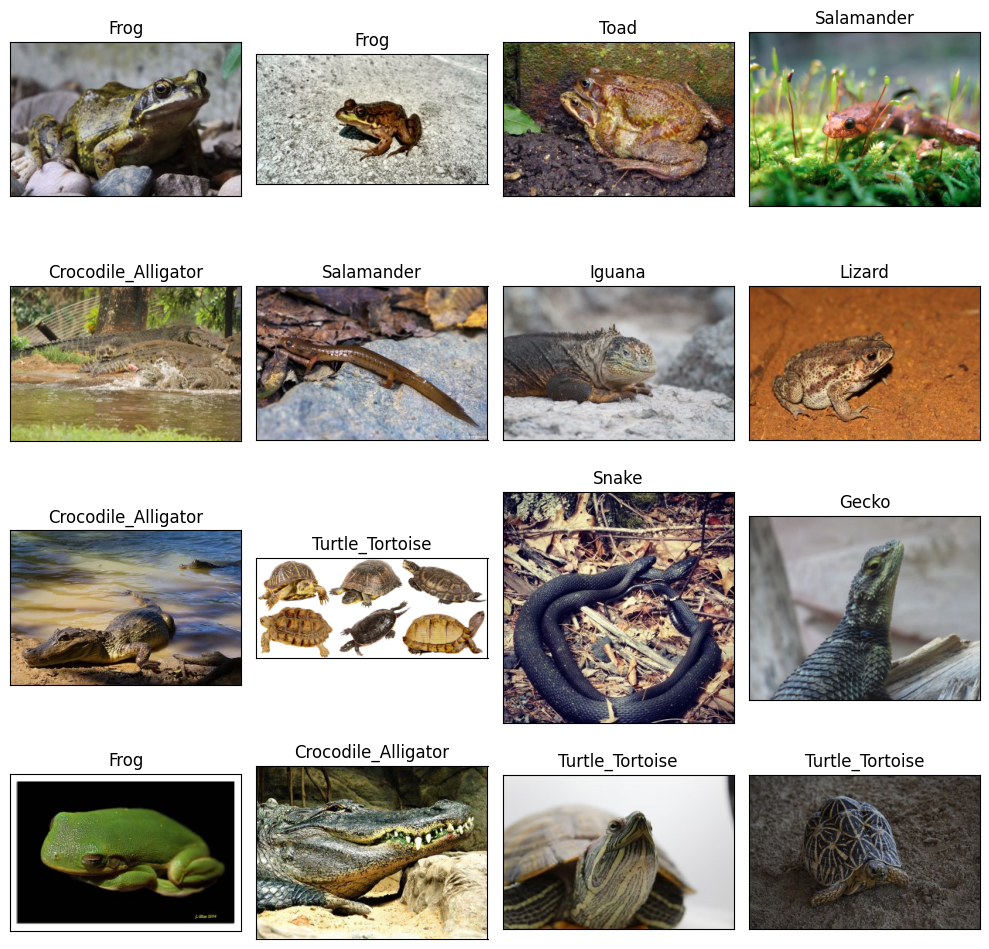

In [3]:

import PIL
from pathlib import Path
from PIL import UnidentifiedImageError

path = Path("../input/reptiles-and-amphibians-image-dataset").rglob("*.JPG")
for img_p in path:
    try:
        img = PIL.Image.open(img_p)
    except PIL.UnidentifiedImageError:
            print(img_p)

# 绘制一个包含 4 行 4 列图像的小图及其标签
# 用 np.random.randint 函数生成一个 16 个元素的随机列表，其中包含 0 到 len(image_df)-1 之间的所有整数，将被用于随机选择图像数据集中的每个图像。
random_index = np.random.randint(0, len(image_df), 16)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 10),
                        subplot_kw={'xticks': [], 'yticks': []})

# 用 for 循环遍历小图的所有坐标轴，对于每个坐标轴，使用 imshow 函数将图像加载到小图中，并使用 set_title 函数将标签显示在标题上。
for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(image_df.Filepath[random_index[i]]))
    ax.set_title(image_df.Label[random_index[i]])

plt.tight_layout()
# tight_layout 函数确保绘图区域紧密排列
plt.show()

# Base de données Train, Val, Test

In [ ]:
train_df, test_df = train_test_split(image_df, test_size=0.2, shuffle=True, random_state=42)

train_generator = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2
)
#preprocessing_function: 用于预处理数据的函数，这里使用的是 MobileNetV2 的 preprocess_input 函数。
#validation_split: 验证集的比例，用于评估模型性能。

test_generator = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)



# Entrainement du modèle

Dans cette section, on va faire un apprentissage du modèle CNN sur nos données. Pour l'apprentissage, il suffit de régler le learning_rate et le batch_size. Vous pouvez commencer un apprentissage avec les valeurs par défaut.

Quelques hyperparamètres à ne pas changer:

early-stopping a été activé. Rappelons qu'il permet deux choses:

- Sauvegarder le meilleur modèle

- Eviter l'apparition du surapprentissage. Il est alors impossible que le meilleur modèle sauvegardé a surappris sur nos données.

calcul de l'erreur de prédiction: categorical_crossentropy mesure l'erreur de classe prédit avec la vérité terrain

calul de la performance de détection: accuracy mesure le nombre de classe bien

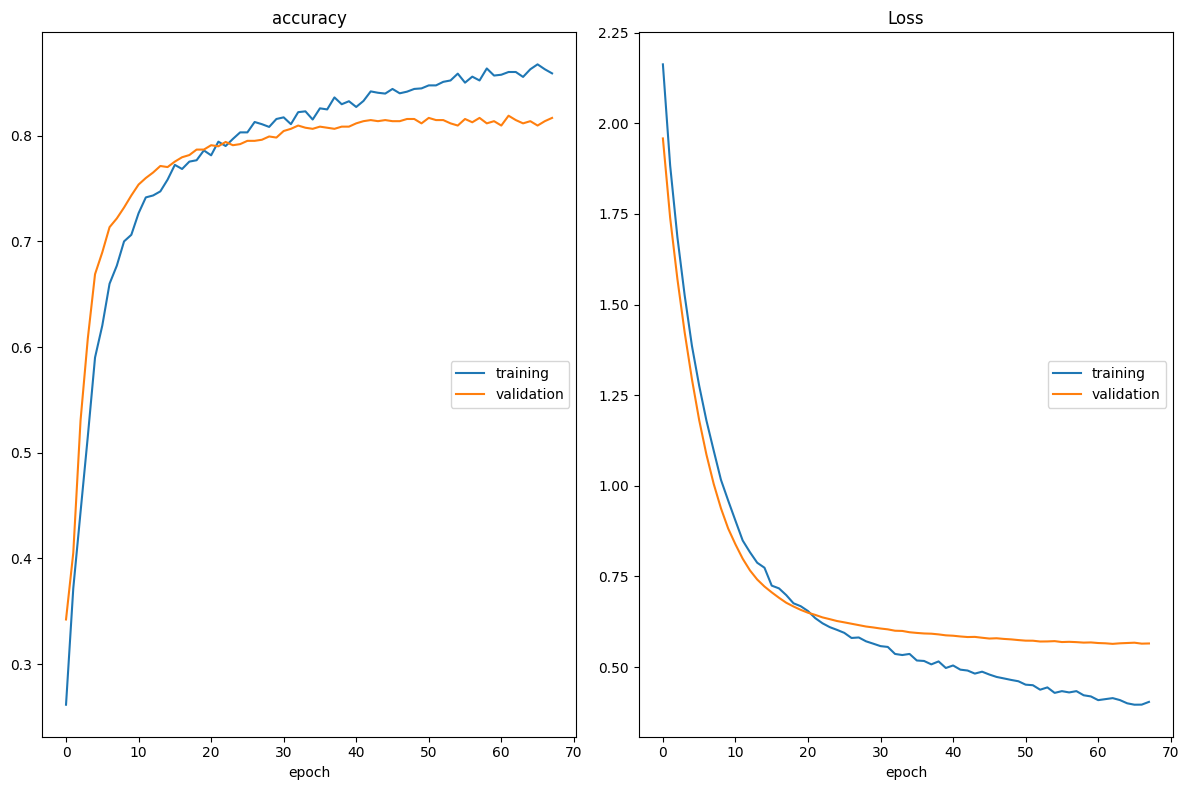

accuracy
	training         	 (min:    0.262, max:    0.868, cur:    0.859)
	validation       	 (min:    0.342, max:    0.819, cur:    0.817)
Loss
	training         	 (min:    0.396, max:    2.163, cur:    0.404)
	validation       	 (min:    0.564, max:    1.958, cur:    0.565)
121/121 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - accuracy: 0.8604 - loss: 0.4062 - val_accuracy: 0.8170 - val_loss: 0.5653
Epoch 68: early stopping


In [10]:
learning_rate = 0.00001 #@param {type:"number"}
batch_size = 32 #@param {type:"number"}

train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True,
    seed=42,
    subset='training'
)

val_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True,
    seed=42,
    subset='validation'
)

test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

# Resize Layer
resize_and_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(224, 224),
    tf.keras.layers.Rescaling(1./255),
])

pretrained_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

pretrained_model.trainable = False

checkpoint_filepath = '/content/best_model.keras'
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    checkpoint_filepath, monitor='val_loss', verbose=1, save_best_only=True,
    save_weights_only=False, mode='auto') #Callback to save the Keras model or model weights at some frequency.


early_stopping = EarlyStopping(monitor = "val_loss", # 观察val损失度量
                               patience = 5,
                               restore_best_weights = True) # 如果val损失连续3个时期减少，则停止训练


early_stopping = EarlyStopping(
    monitor='val_loss', patience=5, verbose=1, mode='auto') #Stop training when a monitored metric has stopped improving.


inputs = pretrained_model.input
x = resize_and_rescale(inputs)
x = Dense(256, activation='relu')(pretrained_model.output)
x = Dropout(0.2)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# Fiting the model
from livelossplot import PlotLossesKeras
plotlossesdeeper = PlotLossesKeras()
history = model.fit(
    train_images,
    steps_per_epoch=len(train_images),
    validation_data=val_images,
    validation_steps=len(val_images),
    epochs=100,
    callbacks=[
        early_stopping,
        create_tensorboard_callback("training_logs",
                                    "animal_classification"),
        checkpoint_callback,
        plotlossesdeeper,
    ]
)

In [13]:
y_test = list(test_df.Label)
model = tf.keras.models.load_model(checkpoint_filepath) #Loading the best model
# res_ = model.evaluate(y_test,y_test,return_dict=True) #Evaluation of the model on the test dataset
# print(res_)

pred = model.predict(test_images)
pred = np.argmax(pred,axis=1)
labels = (train_images.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred = [labels[k] for k in pred]

38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 186ms/step


# Visualisation de la prédiction fait par le modèle

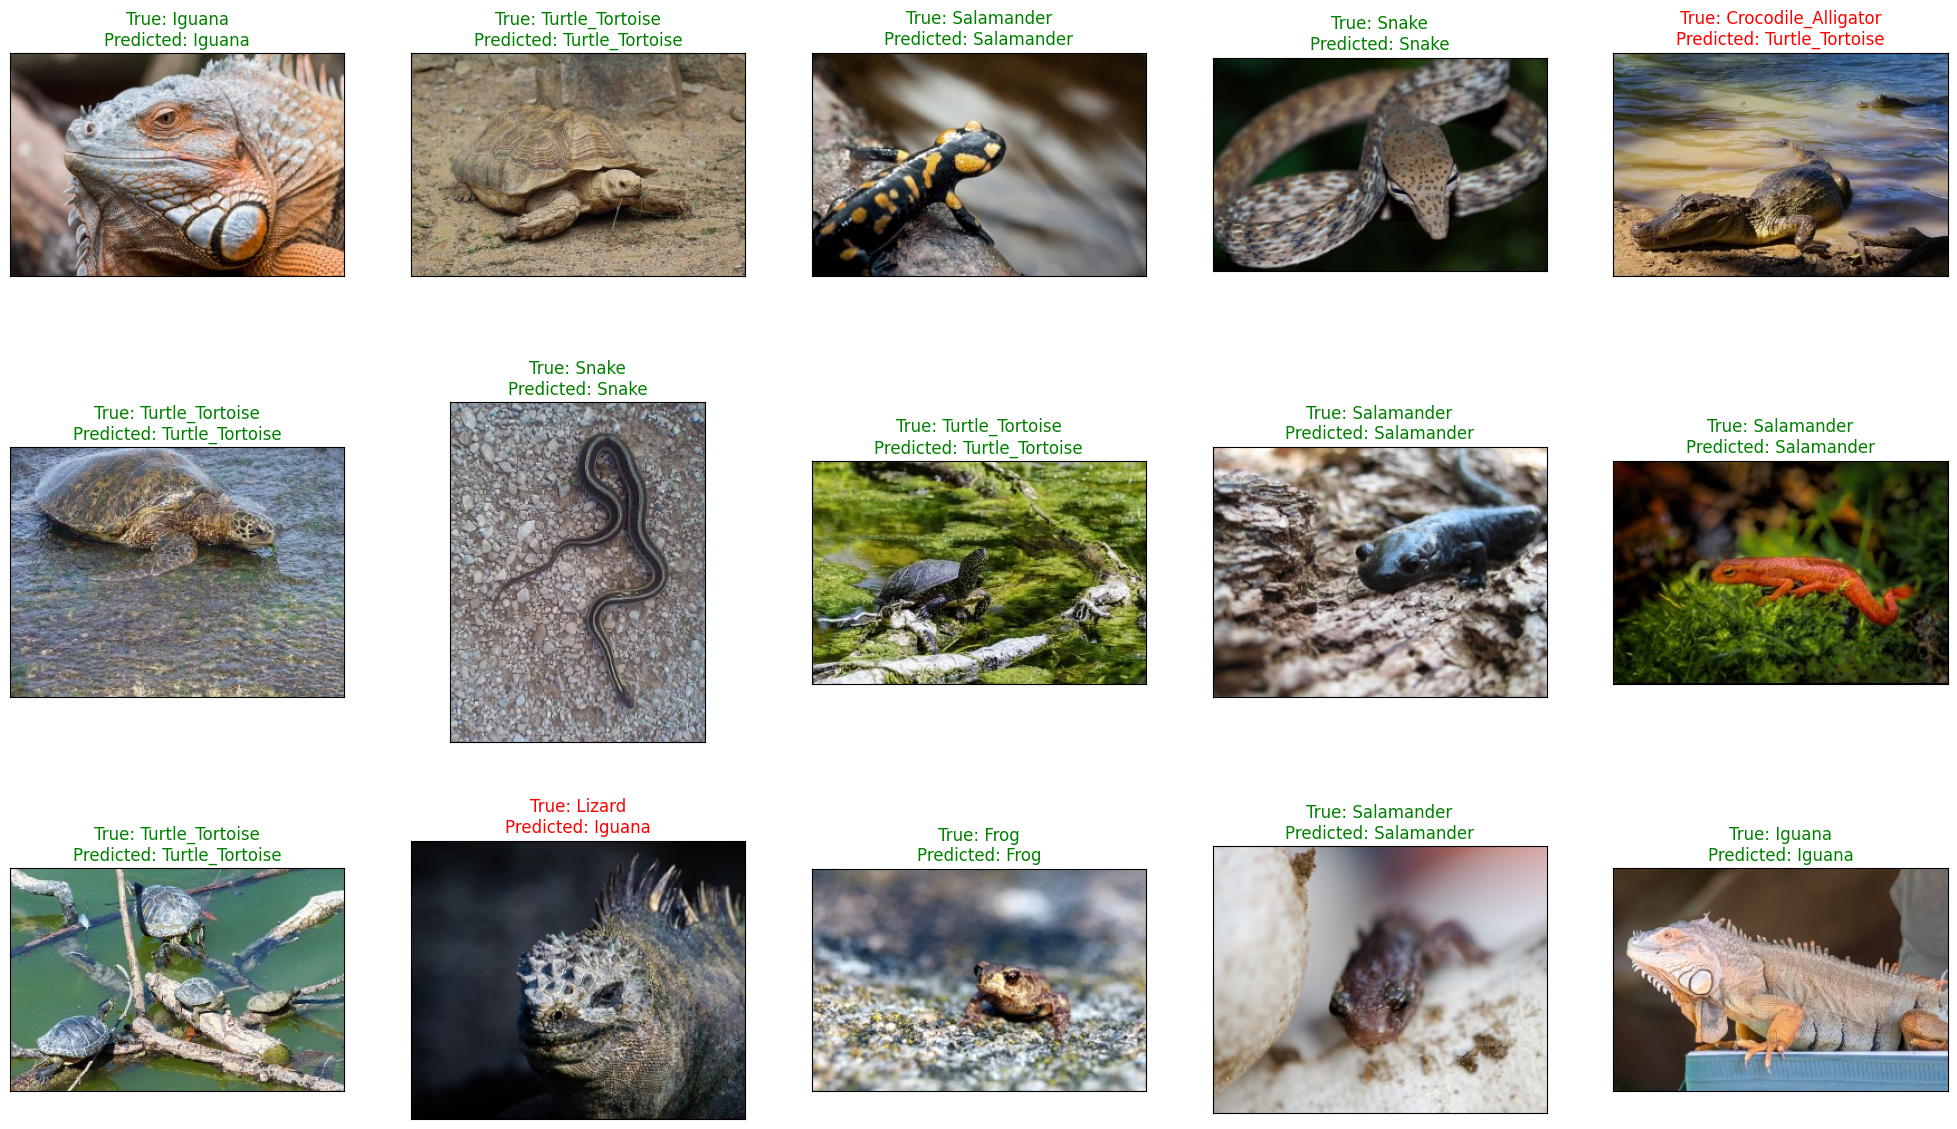

<Figure size 640x480 with 0 Axes>

In [6]:
random_index = np.random.randint(0, len(test_df) - 1, 15)
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(25, 15),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(test_df.Filepath.iloc[random_index[i]]))
    if test_df.Label.iloc[random_index[i]] == pred[random_index[i]]:
      color = "green"
    else:
      color = "red"
    ax.set_title(f"True: {test_df.Label.iloc[random_index[i]]}\nPredicted: {pred[random_index[i]]}", color=color)
plt.show()
plt.tight_layout()

# Analyse des résultats : matrice de confusion

Une matrice de confusion indique le nombre d'exemple d'une classe A comme une classe B.

Sur la diagonale de la matrice, on observe le nombre d'image bien prédit par le modèle.

En dehors de la diagonale, on observe les erreurs du modèle.

QUESTION:

- Quelles sont les espèces bien prédites ?

- Quelles sont les espèces mal prédites (<60%) ? Ces espèces sont confondus avec quel espèce ? Se ressemblent-ils ?

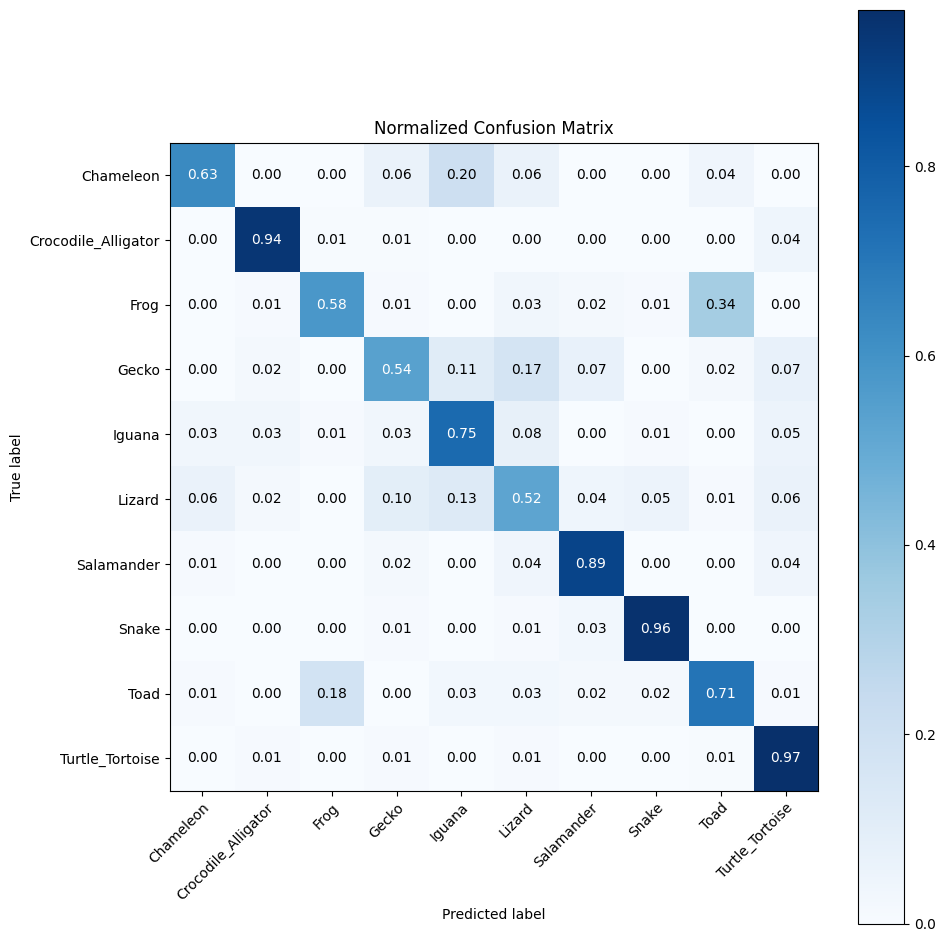

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_test = list(test_df.Label)
report = classification_report(y_test, pred, output_dict=True)
df = pd.DataFrame(report).transpose()
cm = confusion_matrix(y_test, pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=list(labels.values()), yticklabels= list(labels.values()),
       title='Normalized Confusion Matrix',
       ylabel='True label',
       xlabel='Predicted label')

plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
         rotation_mode="anchor")

fmt = '.2f'
thresh = cm_normalized.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm_normalized[i, j], fmt),
                ha="center", va="center",
                color="white" if cm_normalized[i, j] > thresh else "black")
fig.tight_layout()
plt.show()

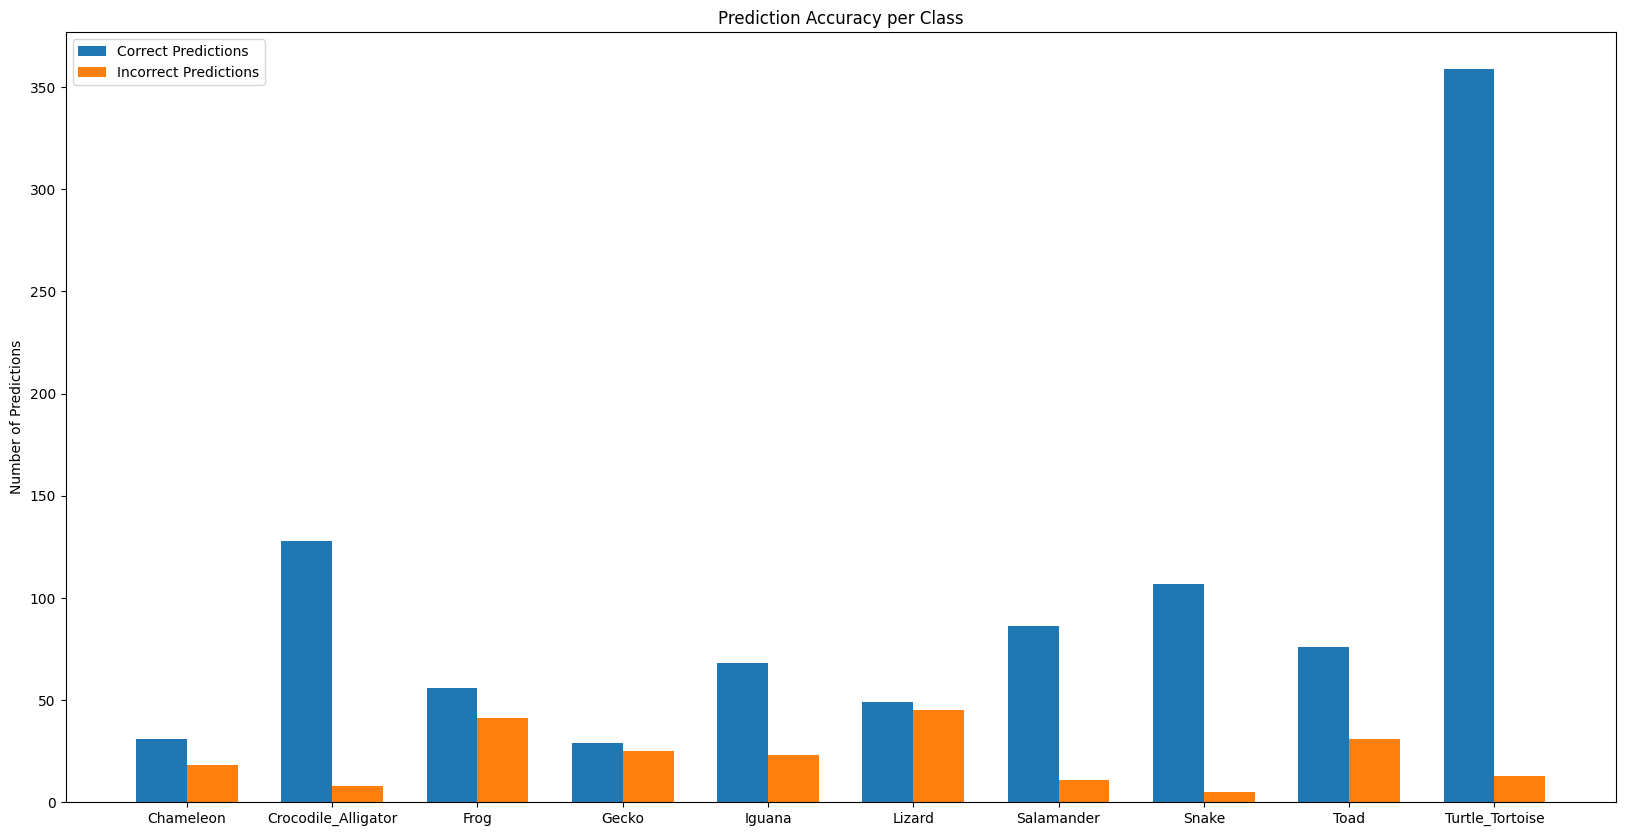

In [47]:
accuracy_per_class(pred,y_test)